##Previsão de Cancelamentos (Churn) de um Hotel

### **O Problema:**
Hotéis enfrentam o desafio dos cancelamentos de última hora, que resultam em quartos vazios, perda de receita e ineficiência operacional na gestão de equipe e insumos. O objetivo foi criar uma inteligência capaz de antecipar quais reservas correm risco real de cancelamento.

##Bibliotecas utilizadas

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
import shap
import joblib
from fastapi import FastAPI
from pydantic import BaseModel
from fastapi.testclient import TestClient
import json

In [ ]:
# instalando shap
!pip install shap

##Dataset utilizado

[Kaggle - Hotel booking demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

##Exploração dos dados

In [ ]:
# carregando dataset
df = pd.read_csv('hotel_bookings.csv')

In [ ]:
# conhecendo os dados
display(df)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [ ]:
# verificando nomes das colunas
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
# verificando cancelamentos
df['is_canceled'].value_counts()

,count
is_canceled,
0,75166
1,44224


In [ ]:
# verificando categorias com dados nulos
df.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


##Hipóteses Formuladas

* H1 (Tipo de Cliente): "Clientes da categoria 'Transient' (passantes) possuem uma taxa de cancelamento estatisticamente diferente dos clientes 'Contract' (empresas/eventos)."

* H2 (Filhos): "Reservas que incluem crianças ou bebês apresentam uma taxa de cancelamento significativamente menor do que reservas apenas de adultos." (A lógica de negócio aqui é que famílias planejam com mais antecedência e têm menos flexibilidade para mudar de ideia).

* H3 (Sazonalidade): "Meses de alta temporada (como Julho e Agosto no hemisfério norte) possuem uma taxa de cancelamento maior devido ao alto volume de reservas feitas com muita antecedência."

##Validação Estatística

###H1 - Clientes da categoria 'Transient' (passantes) possuem uma taxa de cancelamento estatisticamente diferente dos clientes 'Contract' (empresas/eventos).

In [ ]:
# calculando a porcentagem em relação ao total geral de reservas
taxa_total_geral = pd.crosstab(df['customer_type'], df['is_canceled'])
chi2, p_valor, dof, expected = chi2_contingency(taxa_total_geral)

print(f"\nValor p (p-value): {p_valor}")

# conclusão baseada no p-value (usando nível de significância de 0.05 ou 5%)
if p_valor < 0.05:
    print("Rejeitamos a hipótese nula: Existe uma relação estatisticamente significativa entre o tipo de cliente e cancelamento.")
else:
    print("Falhamos em rejeitar a hipótese nula: Não há evidências de que o tipo de cliente afeta o cancelamento.")


Valor p (p-value): 0.0
Rejeitamos a hipótese nula: Existe uma relação estatisticamente significativa entre o tipo de cliente e cancelamento.


In [ ]:
# calculando a porcentagem em relação ao total geral de reservas
taxa_total_geral = pd.crosstab(df['customer_type'], df['is_canceled'], normalize='index') * 100

print("Distribuição Percentual em relação ao Total de Reservas (%):")
display(taxa_total_geral.round(2))

Distribuição Percentual em relação ao Total de Reservas (%):


is_canceled,0,1
customer_type,,
Contract,69.04,30.96
Group,89.77,10.23
Transient,59.25,40.75
Transient-Party,74.57,25.43


###H2 - Reservas que incluem crianças ou bebês apresentam uma taxa de cancelamento significativamente menor do que reservas apenas de adultos.

In [ ]:
# criando a coluna
df['tem_filhos'] = np.where((df['children'] > 0) | (df['babies'] > 0), 'Sim', 'Não')

# verificando a criação
display(df['tem_filhos'].value_counts())

,count
tem_filhos,
Não,110058
Sim,9332


In [ ]:
# criando tabela de contingência
tabela_contingencia = pd.crosstab(df['tem_filhos'], df['is_canceled'])
chi2, p_valor, dof, expected = chi2_contingency(tabela_contingencia)

print(f"\nValor p (p-value): {p_valor}")

# conclusão baseada no p-value (usando nível de significância de 0.05 ou 5%)
if p_valor < 0.05:
    print("Rejeitamos a hipótese nula: Existe uma relação estatisticamente significativa entre ter filhos e cancelamento.")
else:
    print("Falhamos em rejeitar a hipótese nula: Não há evidências de que ter filhos afeta o cancelamento.")


Valor p (p-value): 1.0663070343154822e-05
Rejeitamos a hipótese nula: Existe uma relação estatisticamente significativa entre ter filhos e cancelamento.


In [ ]:
# verificando a porcentagem de quem cancela mais
tabela_contingencia = pd.crosstab(df['tem_filhos'], df['is_canceled'], normalize='index') * 100
display(tabela_contingencia.round(2))

is_canceled,0,1
tem_filhos,,
Não,62.78,37.22
Sim,65.08,34.92


###H3 - Meses de alta temporada (como Julho e Agosto no hemisfério norte) possuem uma taxa de cancelamento maior devido ao alto volume de reservas feitas com muita antecedência.

In [ ]:
cancelamento_meses = pd.crosstab(df['arrival_date_month'], df['is_canceled'])
chi2, p_valor, dof, expected = chi2_contingency(cancelamento_meses)

print(f"\nValor p (p-value): {p_valor}")

# conclusão baseada no p-value (usando nível de significância de 0.05 ou 5%)
if p_valor < 0.05:
    print("Rejeitamos a hipótese nula: Existe uma relação estatisticamente significativa entre o mes de chegada e cancelamento.")
else:
    print("Falhamos em rejeitar a hipótese nula: Não há evidências de que o mes de chegada afeta o cancelamento.")


Valor p (p-value): 3.671822609327152e-119
Rejeitamos a hipótese nula: Existe uma relação estatisticamente significativa entre o mes de chegada e cancelamento.


In [ ]:
# verificando quem cancela mais
cancelamento_meses_2 = pd.crosstab(df['arrival_date_month'], df['is_canceled'], normalize='index') * 100
display(cancelamento_meses_2.round(2))

is_canceled,0,1
arrival_date_month,,
April,59.20,40.80
August,62.25,37.75
December,65.03,34.97
February,66.58,33.42
January,69.52,30.48
July,62.55,37.45
June,58.54,41.46
March,67.85,32.15
May,60.33,39.67


##Vazamento de Dados (Data Leakage) e a análise dos Valores Nulos

In [ ]:
# verificando dados nulos
df.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
# verificando tipos dos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# criando copia do dataset
df_clean = df.copy()

# removendo colunas que causariam vazamento de dados
df_clean = df_clean.drop(['reservation_status','reservation_status_date'], axis = 1)

In [ ]:
# preenchendo a coluna 'country' com um valor fixo
df_clean['country'] = df_clean['country'].fillna('Unknown')

# preenchendo as coluna com nulos com 0
df_clean['children'] = df_clean['children'].fillna(0)
df_clean['agent'] = df_clean['agent'].fillna(0)
df_clean['company'] = df_clean['company'].fillna(0)

# verificando nulos
df_clean.isnull().sum().max()

0

##Feature Engineering

In [ ]:
# total de pessoas
df_clean['total_pessoas'] = df_clean['adults'] + df_clean['children'] + df_clean['babies']
# total de noites
df_clean['total_noites'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
# foi trocado de quarto?
df_clean['mudou_quarto'] = np.where((df_clean['reserved_room_type'] != df_clean['assigned_room_type']), 1, 0)

display(df_clean[['total_pessoas', 'total_noites', 'mudou_quarto']])

,total_pessoas,total_noites,mudou_quarto
0,2.0,0,0
1,2.0,0,0
2,1.0,1,1
3,1.0,1,0
4,2.0,2,0
...,...,...,...
119385,2.0,7,0
119386,3.0,7,0
119387,2.0,7,0
119388,2.0,7,0


## Data Splitting (Divisão dos dados) e Pré-processamento

In [ ]:
# definindo features
X = df_clean[['lead_time', 'adr', 'total_pessoas', 'total_noites', 'mudou_quarto', 'previous_cancellations', 'hotel', 'market_segment', 'deposit_type', 'customer_type', 'tem_filhos']]
y = df_clean['is_canceled']

In [ ]:
# separando os dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# separando colunas numericas e categoricas
col_num = ['lead_time', 'adr', 'total_pessoas', 'total_noites', 'mudou_quarto', 'previous_cancellations']
col_cat = ['hotel', 'market_segment', 'deposit_type', 'customer_type', 'tem_filhos']

In [ ]:
# preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), col_num),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), col_cat)
    ])

In [ ]:
# treinando e transformando dados de treino
X_train_tratado = preprocessor.fit_transform(X_train)
# transformando os dados de teste
X_test_tratado = preprocessor.transform(X_test)

In [ ]:
X_test_tratado.shape

(23878, 20)

In [ ]:
X_train_tratado.shape

(95512, 20)

##Modelagem

In [ ]:
# testando com hyperparameters padrao
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_tratado, y_train)
y_pred_logreg = logreg.predict(X_test_tratado)

print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       0.75      0.96      0.84     14907
           1       0.88      0.45      0.60      8971

    accuracy                           0.77     23878
   macro avg       0.81      0.71      0.72     23878
weighted avg       0.80      0.77      0.75     23878



Teve um Recall de apenas 45%. Isso significa que de cada 100 clientes que realmente iam cancelar, o nosso detetive veterano só conseguiu prever 45, sendo pior que tirar cara ou coroa pra prever o resultado. Os outros 55 ele disse que iam aparecer no hotel. O resultado? O gerente do hotel não se preparou e ficou com 55 quartos vazios.

In [ ]:
# testando com hyperparameters padrao
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_tratado, y_train)
y_pred_rf = rf.predict(X_test_tratado)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86     14907
           1       0.79      0.72      0.75      8971

    accuracy                           0.82     23878
   macro avg       0.81      0.80      0.80     23878
weighted avg       0.82      0.82      0.82     23878



### Modelo escolhido pelo recall superior: RandomForestClassifier

Alcançou um Recall de 72%. Ele capturou a grande maioria dos cancelamentos! Ele teve uma pequena queda na precisão (79%), o que significa que de vez em quando ele dá um alarme falso.

##Otimização de Hiperparâmetros (Tuning)

In [ ]:
parametros_busca = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True],
    'max_samples': [0.7, 0.8, 0.9, None],
    'criterion': ['gini', 'entropy']
}

modelo_base = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

busca = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=parametros_busca,
    n_iter=20,
    cv=3,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

busca.fit(X_train_tratado, y_train)

print("Melhores hiperparâmetros encontrados:", busca.best_params_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Melhores hiperparâmetros encontrados: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_samples': 0.9, 'max_depth': 20, 'criterion': 'entropy', 'bootstrap': True}


In [ ]:
melhor_modelo = busca.best_estimator_
y_pred_melhor_modelo = melhor_modelo.predict(X_test_tratado)

print(classification_report(y_test, y_pred_melhor_modelo))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85     14907
           1       0.74      0.77      0.75      8971

    accuracy                           0.81     23878
   macro avg       0.80      0.80      0.80     23878
weighted avg       0.81      0.81      0.81     23878



## Escolha do melhor modelo

* Primeiro modelo (rf) (Recall 0.72): Ele é mais 'preciso' (79%), mas deixa escapar 28% dos canceladores.

* Segundo modelo (melhor_modelo) (Recall 0.77): Embora a precisão tenha caído para 74%, ele consegue capturar 77% dos cancelados.

O segundo modelo foi escolhido, pois ele te dá uma cobertura maior (Recall) sobre quem realmente vai cancelar, permitindo que o hotel tome ações preventivas em um grupo maior de pessoas, mesmo que algumas delas não fossem cancelar de fato.

Melhores hiperparâmetros encontrados no segundo modelo: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_samples': 0.9, 'max_depth': 20, 'criterion': 'entropy', 'bootstrap': True}

##Explainable AI (XAI)

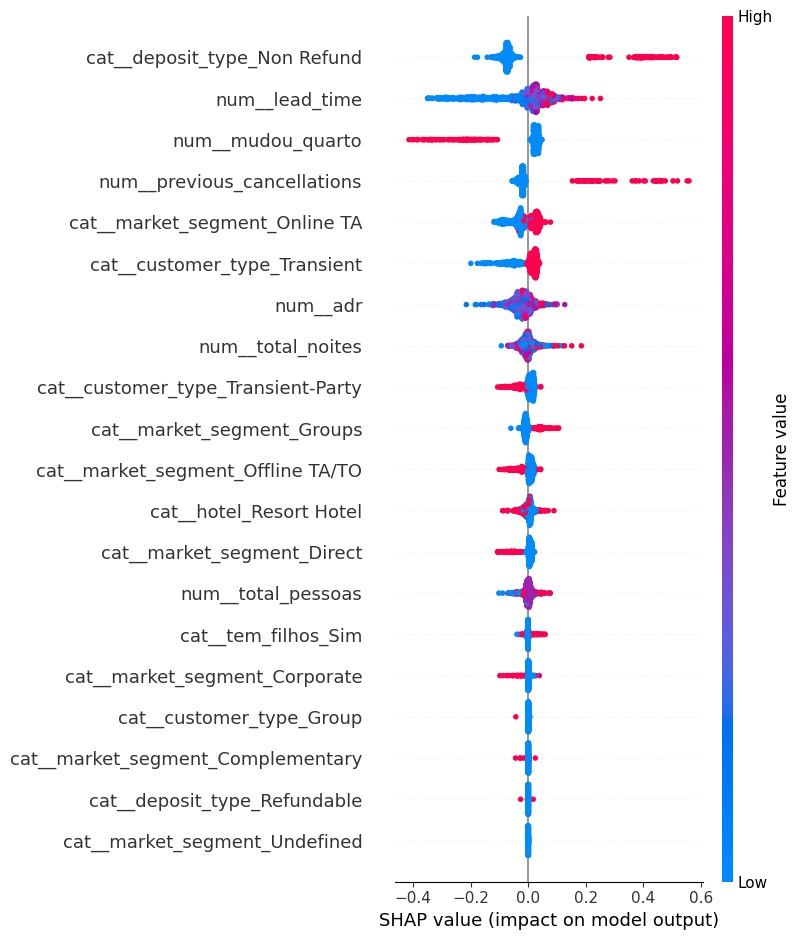

In [ ]:
# nome das features
nomes_features = preprocessor.get_feature_names_out()

# o explicador do modelo
explainer = shap.TreeExplainer(melhor_modelo)

# pegando uma amostra de 10 linhas do X_test_tratado para não travar o PC
X_teste_amostra = np.array(X_test_tratado[:1000])

# calculando os valores SHAP
shap_values = explainer.shap_values(X_teste_amostra)

# gerando o gráfico pra classe [1] o cancelamento
shap.summary_plot(shap_values[:,:,1], X_teste_amostra, feature_names=nomes_features)

###Explicando o modelo baseando-se em resultados de 1000 amostras

* Quanto maior o numero de cancelamentos anteriores, maior a chance de cancelamento.

* Valores maiores do tipo de depósito não reembolsável tem maior chance de cancelamento

* A troca de quarto provavelmente significa um Upgrade Gratuito (ex: o hotel overbookou os quartos standard e passou o cliente para uma suíte) altamente diminuindo a taxa de cancelamento.

* Reservas feitas com menor antecedência, menor a chance de cancelamento e vice-versa.

## Conclusão do Projeto: Previsão de Cancelamentos (Churn)

### **O Problema:**
Hotéis enfrentam o desafio dos cancelamentos de última hora, que resultam em quartos vazios, perda de receita e ineficiência operacional na gestão de equipe e insumos. O objetivo foi criar uma inteligência capaz de antecipar quais reservas correm risco real de cancelamento.

### **A Solução e Impacto:**
Utilizamos um modelo de **Random Forest (Floresta Aleatória)** otimizado para maximizar a captura de cancelamentos.
*   **Resultado:** Alcançamos **77% de Recall**.
*   **O que isso significa?** De cada 100 cancelamentos reais, o modelo identifica corretamente 77 deles com antecedência. Para o gerente do hotel, isso significa a oportunidade de reocupar esses quartos sem riscos de overbooking, reduzindo drasticamente a taxa de ociosidade e protegendo o faturamento.

### **O Insight:**
A análise via **SHAP** revelou um padrão fascinante: **A troca de quarto (Upgrades)**.
Descobrimos que quando o quarto atribuído é diferente do reservado (geralmente um upgrade gratuito por necessidade operacional), a chance de cancelamento despenca.

**Valor de Negócio:** Isso prova que o 'encantamento' do cliente através de upgrades não apenas melhora a experiência, mas é uma ferramenta poderosa para garantir que o cliente não desista da reserva, portanto o aumento de experiências similares como um jantar especial incluso, um passeio ou cupons devem ajudar a diminuir a taxa de cancelamento.

##Deploy e conteinerização

In [ ]:
# salvando o pipeline de transformação dos dados
joblib.dump(preprocessor, 'preprocessor.joblib')

# salvando o modelo treinado
joblib.dump(melhor_modelo, 'modelo.joblib')

['modelo.joblib']

In [ ]:
# carregando o pipeline de transformação dos dados
preprocessor = joblib.load('preprocessor.joblib')

# carregando o modelo treinado
modelo = joblib.load('modelo.joblib')

### API do modelo (main.py)

In [ ]:
app = FastAPI()

class ReservaHotel(BaseModel):
    lead_time: int
    adr: float
    total_pessoas: int
    total_noites: int
    mudou_quarto: int
    previous_cancellations: int
    hotel: str
    market_segment: str
    deposit_type: str
    customer_type: str
    tem_filhos: str

@app.post("/prever_churn")
def prever(cliente: ReservaHotel):
    cliente_dict = cliente.model_dump()
    cliente_df = pd.DataFrame([cliente_dict])
    cliente_tratado = preprocessor.transform(cliente_df)
    predicao = modelo.predict(cliente_tratado)

    return {"churn_predito": int(predicao[0])}

### Teste de Validação da API

In [ ]:
# selecionando os primeiros 15 exemplos do conjunto de teste real
amostra_teste = X_test.head(15)
labels_reais = y_test.head(15).values

print(f"--- Teste de Validação da API ---\n")

# reiniciando o cliente para garantir que pegue a versão mais recente do app
client = TestClient(app)

for i in range(len(amostra_teste)):
    # convertendo a linha do DataFrame para o formato JSON esperado pela API
    dados_cliente = amostra_teste.iloc[i].to_dict()

    # fazendo a chamada para a API
    response = client.post("/prever_churn", json=dados_cliente)
    predicao = response.json()["churn_predito"]

    status = "✅ ACERTOU" if predicao == labels_reais[i] else "❌ ERROU"

    print(f"Exemplo {i+1}:")
    print(f" - Real: {labels_reais[i]} | Predito pela API: {predicao}")
    print(f" - Resultado: {status}")
    print("-" * 30)

--- Teste de Validação da API ---

Exemplo 1:
 - Real: 0 | Predito pela API: 0
 - Resultado: ✅ ACERTOU
------------------------------
Exemplo 2:
 - Real: 1 | Predito pela API: 1
 - Resultado: ✅ ACERTOU
------------------------------
Exemplo 3:
 - Real: 0 | Predito pela API: 0
 - Resultado: ✅ ACERTOU
------------------------------
Exemplo 4:
 - Real: 0 | Predito pela API: 0
 - Resultado: ✅ ACERTOU
------------------------------
Exemplo 5:
 - Real: 0 | Predito pela API: 1
 - Resultado: ❌ ERROU
------------------------------
Exemplo 6:
 - Real: 0 | Predito pela API: 1
 - Resultado: ❌ ERROU
------------------------------
Exemplo 7:
 - Real: 1 | Predito pela API: 0
 - Resultado: ❌ ERROU
------------------------------
Exemplo 8:
 - Real: 0 | Predito pela API: 0
 - Resultado: ✅ ACERTOU
------------------------------
Exemplo 9:
 - Real: 0 | Predito pela API: 1
 - Resultado: ❌ ERROU
------------------------------
Exemplo 10:
 - Real: 0 | Predito pela API: 0
 - Resultado: ✅ ACERTOU
-------------

### Resultado da Validação

O modelo acertou 11 de 15, mantendo uma acurácia de 73.33 %.

#**Obrigado por acompanhar o projeto!**